In [1]:
from qsnow.helpers import serialize
from qsnow.interface import *
from qsnow.experiments import *
from qsnow.visualize import *

%load_ext autoreload
%aimport qsnow.interface
%aimport qsnow.interface
%aimport qsnow.visualize
%aimport qsnow.helpers.serialize
%aimport qsnow.experiments
%autoreload 2

import os
import sys

# The kernel starts in this notebook's directory, so scripts/ is relative to it
# (`__file__` doesn't exist in a kernel).
sys.path.insert(0, os.path.abspath("scripts"))

import calib_histograms
import calib_vs_chip

from pathlib import Path
from time import perf_counter

import argparse
import logging

import plotly.io as pio
pio.templates["paper"] = pio.templates["plotly"]
pio.templates["paper"].layout.font.size = 18
pio.templates["paper"].layout.font.family = "Times New Roman"
pio.templates["paper"].layout.font.color = "black"
pio.templates.default = "paper"

import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rc('legend', fontsize=18)

# logger = logging.getLogger(__name__)
# logging.basicConfig(level=logging.INFO)

from qsnow.visualize.profiling import ler_cdf, ler_histogram, load_profile_runs

_DEFAULT_SEED = 526252849
_DEFAULT_SEED_2 = 948252625

## Helpers

def on_operation(op: str, trig, before, after, name = None) -> InjectionRule:
    return InjectionRule(op, trig, before, after, name = name)

def apply_channel(channel, filter, scalar = 1.0, name = None, source = "qubit_mean"):
    return ChannelRule(channel, filter, scalar=scalar, name=name, source=source)


## Runner Helper
def run(chip: Chip, tiles: List[SCTile], shots, max_errors, min_errors, max_topup_shots, additional_label = 'DATE', data_directory=None, save = True):
    if data_directory:
        serialize.set_data_dir(data_directory)
    start = perf_counter()
    results = []
    for tile in tiles:
        d = tile.spec.distance
        logger.info(f'Beginning profiling for distance {d}....')
        new_chip = chip.copy()
        label = (f'{additional_label}_' if additional_label else '') + f'd{d}_{new_chip.unit_dims[0]}x{new_chip.unit_dims[1]}'
        exp = SquarePackingExp(new_chip, tile)
        exp.tag.name = additional_label + f'_d{d}'
        exp.run(shots=shots, max_errors=max_errors, min_errors=min_errors, max_topup_shots=max_topup_shots)
        if save:
            exp_path = exp.save(label=label)
            res_path = exp.save_results(label=label)
            logger.info(f"Experiment saved to {exp_path}")
            logger.info(f"Results saved to {res_path}")
        results.append([exp, exp.results])

    m, s  = divmod(perf_counter() - start, 60)
    time_str = f'{int(m)} mins, {s:.2g} secs' if m else f'{s:.2g} secs'
    logger.info(f'Completed profiling for {len(tiles)} distance(s) in {time_str}')
    return results

## Demo Data

In [2]:
from qsnow.interface.lattice import SQUARE
import numpy as np
# A dense-lattice device with independently measured qubit and coupler rates: couplers
# average roughly an order of magnitude worse, as they do on real hardware.
rng = np.random.default_rng(7)
device_demo = Chip(10, 12, lattice=SQUARE)
for q in device_demo.qubits:
    q.noise.p = float(np.clip(rng.lognormal(np.log(0.004), 0.40), 1e-6, 0.7))
for cp in device_demo.couplers:
    cp.noise.p = float(np.clip(rng.lognormal(np.log(0.020), 0.55), 1e-6, 0.7))
device_demo.show(style=device_heatmap_style(device_demo, labels=True, label_size=9, axis_labels=True))

## IBM Phoenix Calibration Data Results

dropped empty panel(s): rz gate_error


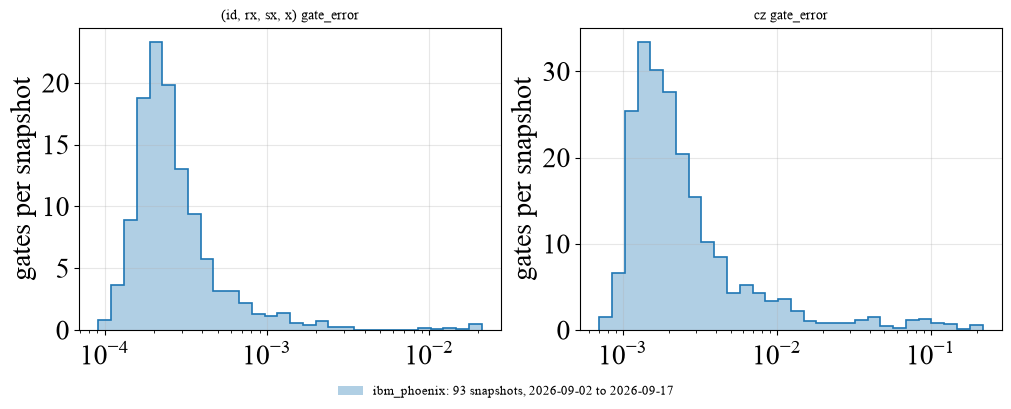

In [3]:
fig = calib_histograms.plot_histograms(devices=['ibm_phoenix'], 
                                       calibration_dir=Path('./data/calibration_data'), 
                                       snapshots = None, 
                                       include=['(id, rx, sx, x) gate_error', 'cz gate_error'],
                                       size=(10,4),
                                       keep_dead=True)

## Chip & Tile Creation

In [4]:
device = Chip(30,30)

# Slope here is l (listed as 4 in the paper since l uses the space that a distance 3 RSC tile would occupy which is 3 unit cells + 1, thus we call l=4 in the paper for brevity
qubit_site_ped = LogSkewContour(location=0.000227, deviation=0.176, skew=0.675, center='median', seed=_DEFAULT_SEED, slope=3)
coupler_ped = LogSkewContour(location=0.00185, deviation=.245, skew=0.956, center='median', seed=_DEFAULT_SEED_2, slope=3)

device.generate_noise(qubit_site_ped)
device.generate_coupler_noise(coupler_ped, correlation=0.2)

In [5]:
device_uniform = Chip(30,30)

device_uniform.generate_noise(Uniform(0.000227))
device_uniform.generate_coupler_noise(Uniform(0.00185))

In [6]:
device_uniform_mean = Chip(30,30)

device_uniform_mean.generate_noise(Uniform(0.00026))
device_uniform_mean.generate_coupler_noise(Uniform(0.00245))

In [7]:
ruleset = Ruleset(
            [
                on_operation(
                    "R",
                    "all_qubits",
                    before=[],
                    after=[apply_channel("X_ERROR", "all_qubits", 20, name='Init')],           #InitZ(p)           -> SI1000(2p) -> SI1000v2(20p_q)
                ),
                on_operation(
                    "H",
                    "x_measures",
                    before=[],
                    after=[
                            apply_channel("DEPOLARIZE1", "active", 1, name='Clifford1'),       #AnyClifford1(p)    -> SI1000(p/10)  -> SI1000v2(p_q)
                            apply_channel("DEPOLARIZE1", "idle", 1, name='Idle'),              #Idle(p)            -> SI1000(p/10) -> SI1000v2(p_q)
                        ],
                ),
                on_operation(
                    "CX",
                    "any",
                    before=[],
                    after=[
                        apply_channel("DEPOLARIZE2", "active", 1, name='Clifford2', source="coupler"),  #AnyClifford2(p)   -> SI1000(p) -> SI1000v2(p_c)
                        apply_channel("DEPOLARIZE1", "idle", 1, name='Idle'),                #Idle(p)           -> SI1000(p/10) -> SI1000v2(p_q)
                    ],
                ),
                on_operation(
                    "MR",
                    "all_measures",
                    before=[
                        apply_channel("X_ERROR", "all_measures", 50, name='Measure'),        #Measure(p)        -> SI1000(5p) -> SI1000v2(50p_q)
                        apply_channel("DEPOLARIZE1", "idle", 20, name='ResonatorIdle'),      #ResonatorIdle(p)  -> SI1000(2p) -> SI1000v2(20p_q)
                        apply_channel("DEPOLARIZE1", "idle", 1, name='Idle'),                #Idle(p)           -> SI1000(p/10) -> 
                    ],
                    after=[
                        apply_channel("X_ERROR", "all_measures", 20, name='Init'),           #InitZ(p)          -> SI1000(2p) -> SI1000v2(20p_q)
                        apply_channel("DEPOLARIZE1", "idle", 20, name='ResonatorIdle'),      #ResonatorIdle(p)  -> SI1000(2p) -> SI1000v2(20p_q)
                        apply_channel("DEPOLARIZE1", "idle", 1, name='Idle'),                #Idle(p)           -> SI1000(p/10) -> SI1000v2(p_q)
                    ],
                ),
                on_operation(
                    "M",
                    "data",
                    before=[
                        apply_channel("X_ERROR", "all_qubits", 50),                          #Measure(p)        -> SI1000(5p) -> SI1000v2(50p_q)
                        apply_channel("DEPOLARIZE1", "idle", 20),                            #ResonatorIdle(p)  -> SI1000(2p) -> SI1000v2(20p_q)
                    ],
                    after=[],
                ),
            ]
        )

tiles = []
for d in [3,5,7,9,11,13,15,17,19,21,23]:
    tile = SCTile(d)
    tile.ruleset = ruleset
    tiles.append(tile)

## Heatmap and Physical Distribution

In [8]:
device = serialize.import_latest('DATE_case_contour_device*')
device.show(device_heatmap_style(device, log = True, axis_labels=False))

Found 1 matching flakes...
Importing flake at /Users/jakepalmer/Code/Projects/qSNOW/data/chips/chip_DATE_case_contour_device_2026-09-19_14-25-27.flake


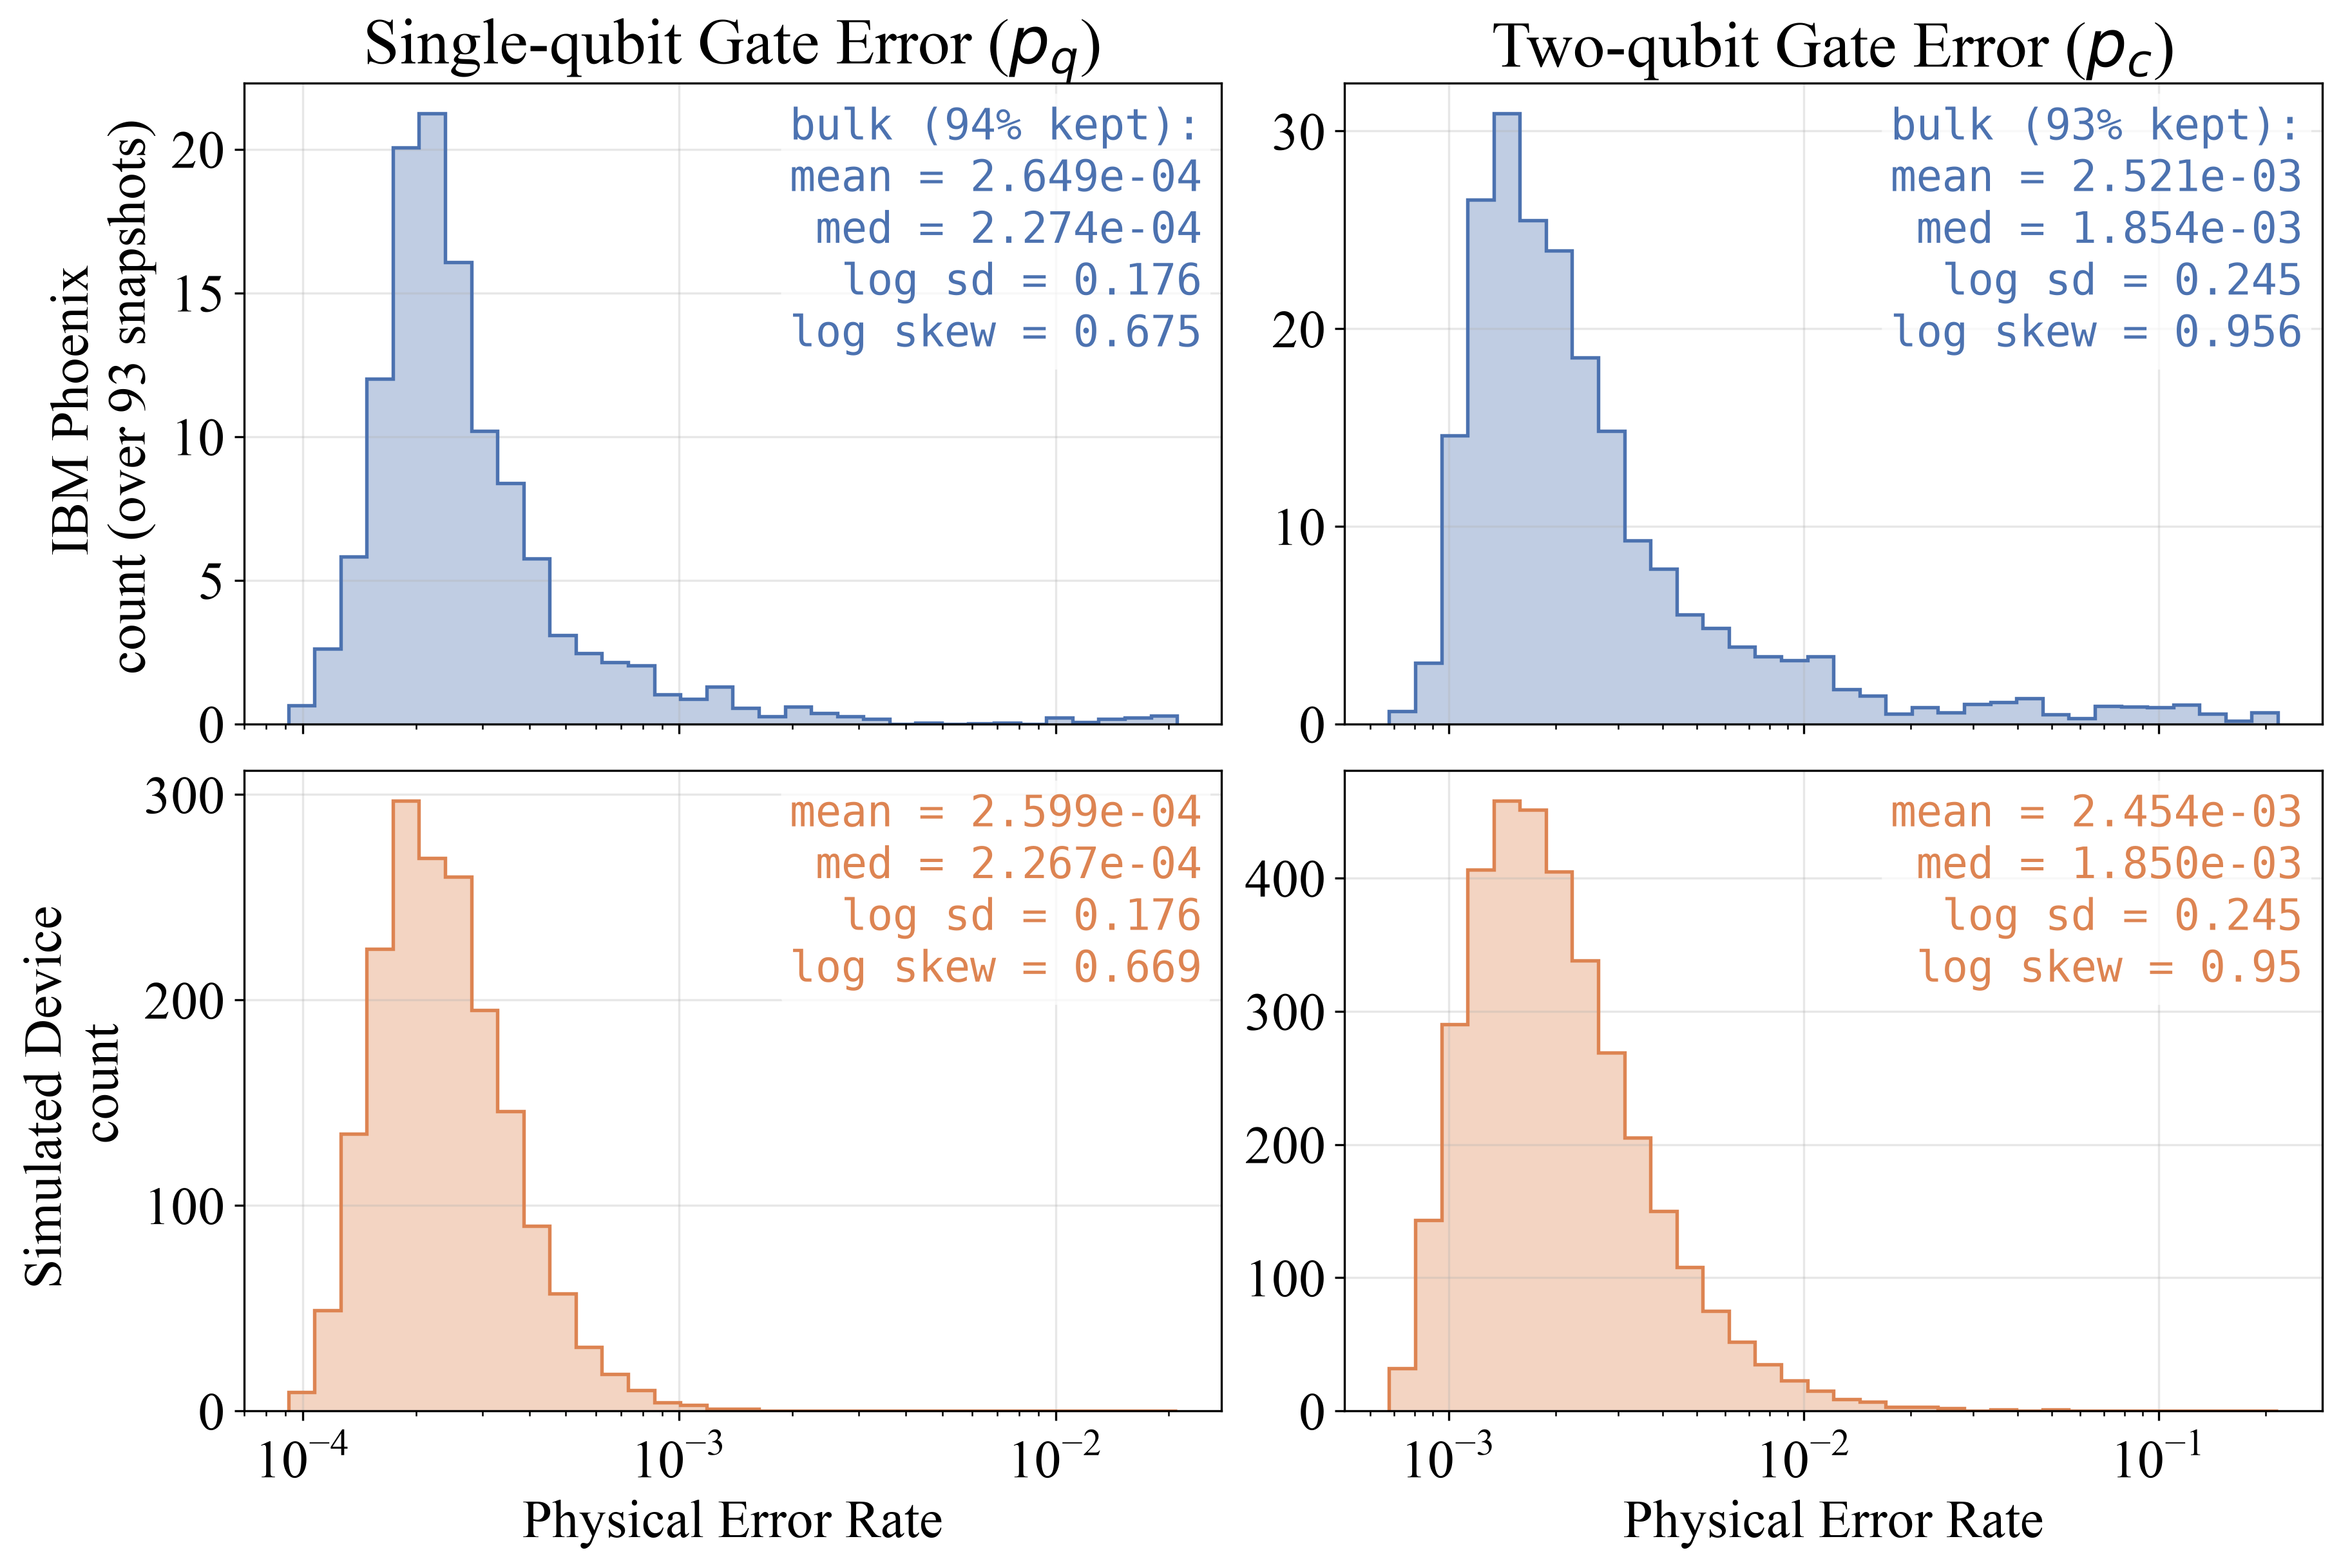

In [ ]:

fig = calib_vs_chip.calib_vs_chip(device, calibration_dir=Path('./data/calibration_data'), size=(12, 8), stats_fontsize=16, dpi=300, 
                                  ylabel_top='IBM Phoenix \n count (over 93 snapshots)',
                                  ylabel_bottom='Simulated Device \n count',
                                  stats_stacked=True,
                                  stats_condense=True,
                                  column_titles=(r'Single-qubit Gate Error ($p_q$)', r'Two-qubit Gate Error ($p_c$)'))

In [10]:
calib_vs_chip.stats_table(calibration_dir=Path('./data/calibration_data'))

ibm_phoenix: 93 snapshots, 2026-09-02 to 2026-09-17
Panel                       Components  Dead  Pooled            Kept  Dropped  Upper fence  Data max
--------------------------  ----------  ----  ------  --------------  -------  -----------  --------
(id, rx, sx, x) gate_error         120     1  11,067  10,403 (94.0%)      664     0.000803     0.021
cz gate_error                      218     4  19,902  18,489 (92.9%)    1,413       0.0114     0.217
(Tukey k=1.5 fences on log10 of the pooled positive values; dead = roster entries with no usable value in any snapshot)


,panel,components,dead,pooled,kept,dropped,kept_frac,lower_fence,upper_fence,data_max
0,"(id, rx, sx, x) gate_error",120,1,11067,10403,664,0.940002,0.000077,0.000803,0.021033
1,cz gate_error,218,4,19902,18489,1413,0.929002,0.000399,0.011364,0.216707


## Experiment Runner



In [ ]:
# Runs Simulated Device model
# results = run(device, tiles,
#               shots = 100_000,
#               max_errors = 10_000,
#               min_errors = 30,
#               max_topup_shots = 2_000_000,
#               data_directory='./data/case_profiling/',
#               additional_label='DATE_100k_')

In [ ]:
# Runs Uniform(p=median)
# results_uniform = run(device_uniform_mean, tiles,
#                         shots = 100_000,
#                         max_errors = 10_000,
#                         min_errors = 30,
#                         max_topup_shots = 2_000_000,
#                         data_directory='./data/case_profiling/uniform_mean/',
#                         additional_label='uniform_mean_DATE_100k')

In [ ]:
# Runs Uniform(p=mean)
# results_uniform = run(device_uniform, tiles,
#                         shots = 100_000,
#                         max_errors = 10_000,
#                         min_errors = 30,
#                         max_topup_shots = 2_000_000,
#                         data_directory='./data/case_profiling/uniform/',
#                         additional_label='uniform_DATE_100k')

## Experiment Visuals

In [11]:
from qsnow.visualize.profiling import ler_cdf, ler_histogram, load_profile_runs, ler_table

directory = 'data/case_profiling/simulated_Device/'
# baseline_median_directory = 'data/case_profiling/uniform_median'
baseline_mean_directory = 'data/case_profiling/uniform_mean'
distances = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23]

runs = load_profile_runs(distances, directory = directory)
baseline_runs = load_profile_runs(distances, directory = baseline_mean_directory)

Distance 3 	:->  range= 0.12433;	 pdif= 18.293;	 mean=0.02834;	 dev=0.01911
Distance 5 	:->  range= 0.09079;	 pdif= 23.641;	 mean=0.02124;	 dev=0.01747
Distance 7 	:->  range= 0.06526;	 pdif= 34.467;	 mean=0.01425;	 dev=0.01328
Distance 9 	:->  range= 0.04331;	 pdif= 40.373;	 mean=0.00863;	 dev=0.00903
Distance 11 	:->  range= 0.0282;	 pdif= 48.797;	 mean=0.00475;	 dev=0.00558
Distance 13 	:->  range= 0.01767;	 pdif= 48.757;	 mean=0.00238;	 dev=0.00298
Distance 15 	:->  range= 0.0073808;	 pdif= 27.435;	 mean=0.00112;	 dev=0.00121
Distance 17 	:->  range= 0.0025343;	 pdif= 19.673;	 mean=0.00055;	 dev=0.00043
Distance 19 	:->  range= 0.0010503;	 pdif= 11.533;	 mean=0.00032;	 dev=0.00018
Distance 21 	:->  range= 0.00046207;	 pdif= 7.8024;	 mean=0.00021;	 dev=0.00009
Distance 23 	:->  range= 0.00027039;	 pdif= 6.4502;	 mean=0.00014;	 dev=0.00005

Chip(mean=0.00025990549227442587, dev=0.0001287317386207892, min=9.329186730425512e-05, max=0.0016052546335136428)


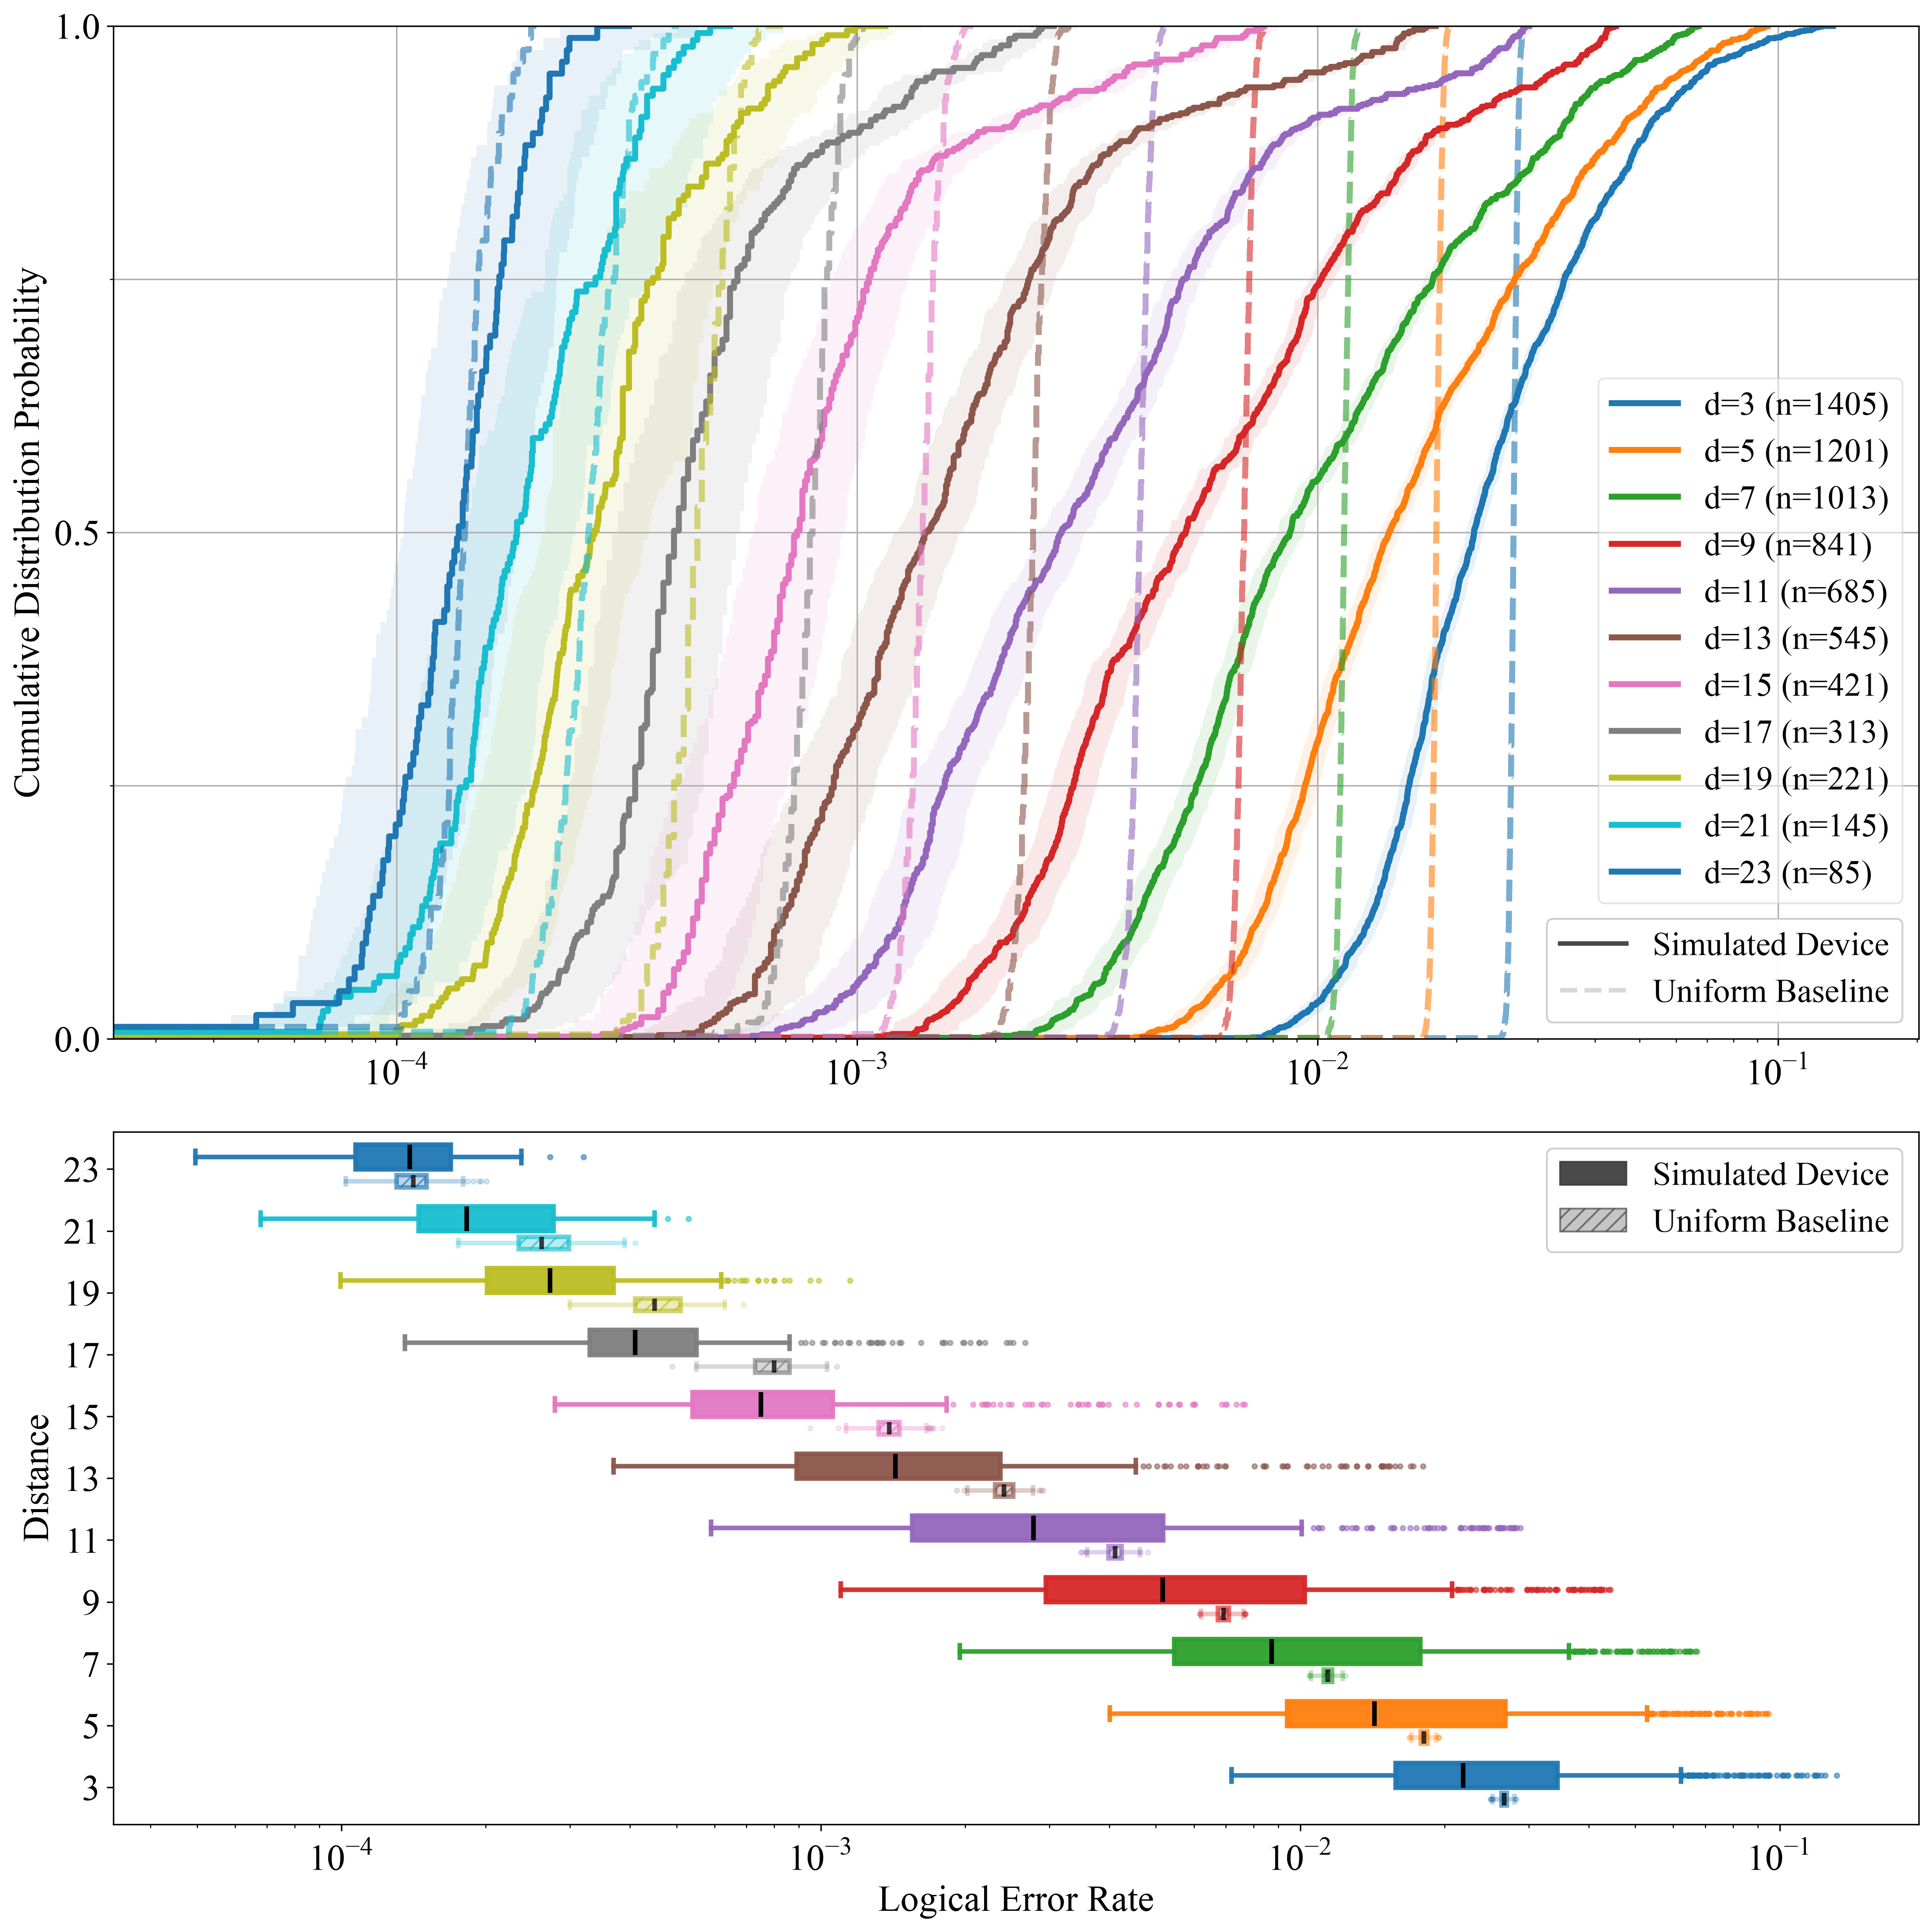

In [12]:
ler_cdf(distances, directory, 
        baseline_dir=baseline_mean_directory, 
        band=True, band_alpha=0.1, 
        title=None, labels=('Simulated Device', 'Uniform Baseline'), 
        baseline_alpha = .6, linewidth=3.25,
        box_scale=1.2, box_linewidth=2.5,
        dpi=300, 
        figsize=(15, 15))

In [13]:
ler_table(distances, directory, baseline_dir=baseline_mean_directory, explain=True, verbose=True)


Distance 3
  stat                log skewed contour uniform homogeneous      ratio
  n                                 1405                1405          1
  best                           0.00719             0.02495     0.2882
  p5                             0.01062             0.02578     0.4118
  median                         0.02185             0.02662     0.8208
  p95                            0.06758             0.02747       2.46
  worst                           0.1315             0.02818      4.667
  spread p95/p5                    6.366               1.066      5.974
  spread worst/best                18.29               1.129       16.2
  CV                              0.6743             0.01932       34.9
  yield                                0                   0          0

Distance 5
  stat                log skewed contour uniform homogeneous      ratio
  n                                 1201                1201          1
  best                           0.00401

[{'distance': 3,
  'stat': 'n',
  'log skewed contour': 1405.0,
  'uniform homogeneous': 1405.0,
  'ratio': 1.0},
 {'distance': 3,
  'stat': 'best',
  'log skewed contour': 0.00719,
  'uniform homogeneous': 0.02495,
  'ratio': 0.2881763527054108},
 {'distance': 3,
  'stat': 'p5',
  'log skewed contour': 0.010616,
  'uniform homogeneous': 0.02578,
  'ratio': 0.41179208688906127},
 {'distance': 3,
  'stat': 'median',
  'log skewed contour': 0.02185,
  'uniform homogeneous': 0.02662,
  'ratio': 0.8208114199849738},
 {'distance': 3,
  'stat': 'p95',
  'log skewed contour': 0.06757999999999997,
  'uniform homogeneous': 0.02747,
  'ratio': 2.46013833272661},
 {'distance': 3,
  'stat': 'worst',
  'log skewed contour': 0.13152465844069908,
  'uniform homogeneous': 0.02818,
  'ratio': 4.667305125645815},
 {'distance': 3,
  'stat': 'spread p95/p5',
  'log skewed contour': 6.365862848530517,
  'uniform homogeneous': 1.0655546935609,
  'ratio': 5.974224398802939},
 {'distance': 3,
  'stat': 'sprea